In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim import corpora, models
from gensim.models import CoherenceModel
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_sentiment.csv", low_memory=False)
print(f"Loaded {len(df):,} reviews")

Loaded 124,108 reviews


In [2]:
df_lda = df[df['word_count'] >= 5].copy()
print(f"Reviews for LDA: {len(df_lda):,}")

df_lda['tokens'] = df_lda['review_clean'].str.split()

from collections import Counter
all_words = [word for tokens in df_lda['tokens'] for word in tokens]
word_freq = Counter(all_words)

N = len(df_lda)
MIN_FREQ = 20
MAX_FREQ_RATIO = 0.8

keep_words = {word for word, count in word_freq.items()
              if count >= MIN_FREQ and count / N <= MAX_FREQ_RATIO}

df_lda['tokens_filtered'] = df_lda['tokens'].apply(
    lambda tokens: [t for t in tokens if t in keep_words]
)

dictionary = corpora.Dictionary(df_lda['tokens_filtered'])
corpus = [dictionary.doc2bow(tokens) for tokens in df_lda['tokens_filtered']]

print(f"Vocabulary size: {len(dictionary):,} unique words")
print(f"Corpus size: {len(corpus):,} documents")

Reviews for LDA: 108,122
Vocabulary size: 5,974 unique words
Corpus size: 108,122 documents


Finding optimal number of topics (this takes 10-15 minutes)...
  k=5: coherence=0.4140
  k=7: coherence=0.4719
  k=9: coherence=0.4742
  k=11: coherence=0.4681
  k=13: coherence=0.4721
  k=15: coherence=0.4937
  k=17: coherence=0.4796
  k=19: coherence=0.4943


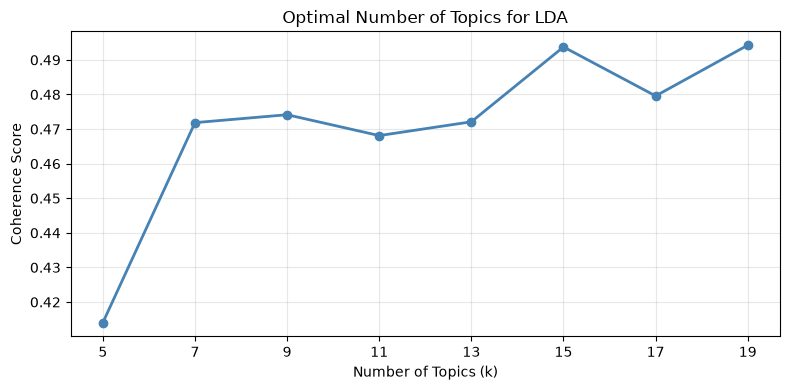


Best k: 19 (coherence: 0.4943)


In [3]:
print("Finding optimal number of topics (this takes 10-15 minutes)...")

coherence_scores = []
k_range = range(5, 21, 2)

for k in k_range:
    model = models.LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        workers=2
    )
    coherence = CoherenceModel(
        model=model, texts=df_lda['tokens_filtered'].tolist(),
        dictionary=dictionary, coherence='c_v'
    ).get_coherence()
    coherence_scores.append((k, coherence))
    print(f"  k={k}: coherence={coherence:.4f}")

ks, scores = zip(*coherence_scores)
plt.figure(figsize=(8, 4))
plt.plot(ks, scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Topics (k)')
plt.ylabel('Coherence Score')
plt.title('Optimal Number of Topics for LDA')
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/04_lda_coherence.png', dpi=150)
plt.show()

best_k = ks[scores.index(max(scores))]
print(f"\nBest k: {best_k} (coherence: {max(scores):.4f})")

In [4]:
BEST_K = 15

print(f"Training final LDA model with k={BEST_K}...")

lda_model = models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=BEST_K,
    random_state=42,
    passes=10,
    workers=2,
    alpha='asymmetric'
)

print(f"\nTop words per topic (k={BEST_K}):\n")
for topic_id in range(BEST_K):
    words = lda_model.show_topic(topic_id, topn=10)
    word_list = [f"{w}({p:.2f})" for w, p in words]
    print(f"Topic {topic_id:2d}: {', '.join(word_list)}")

Training final LDA model with k=15...

Top words per topic (k=15):

Topic  0: card(0.12), sim(0.12), que(0.03), muy(0.03), con(0.02), dual(0.02), telefono(0.02), slot(0.01), excelente(0.01), para(0.01)
Topic  1: great(0.06), work(0.05), new(0.04), love(0.02), good(0.02), condition(0.02), product(0.02), like(0.02), happy(0.02), came(0.02)
Topic  2: great(0.05), good(0.05), battery(0.03), camera(0.03), price(0.03), life(0.02), fast(0.02), use(0.02), quality(0.02), really(0.02)
Topic  3: call(0.03), time(0.02), get(0.02), work(0.02), like(0.02), screen(0.02), text(0.02), would(0.01), message(0.01), back(0.01)
Topic  4: unlocked(0.04), version(0.02), product(0.02), model(0.02), international(0.02), seller(0.01), bought(0.01), amazon(0.01), received(0.01), unlock(0.01)
Topic  5: apps(0.03), nokia(0.01), app(0.01), update(0.01), moto(0.01), android(0.01), google(0.01), use(0.01), also(0.01), like(0.01)
Topic  6: call(0.04), button(0.04), speaker(0.04), sound(0.03), volume(0.02), hear(0.02), 

In [5]:
TOPIC_LABELS = {
    0: 'International Reviews',
    1: 'General Satisfaction',
    2: 'Overall Value',
    3: 'Calling & Messaging',
    4: 'Unlocked & International Buying',
    5: 'Software & Apps',
    6: 'Audio & Sound',
    7: 'Packaging & Accessories',
    8: 'Screen & Design',
    9: 'Battery Life',
    10: 'Brand Comparison',
    11: 'Network & Carriers',
    12: 'Purchase Decision',
    13: 'Problems & Returns',
    14: 'Camera Quality',
}

print("Topic labels assigned:\n")
for k, v in TOPIC_LABELS.items():
    words = [w for w, _ in lda_model.show_topic(k, topn=5)]
    print(f"  Topic {k:2d} ({v}): {', '.join(words)}")

Topic labels assigned:

  Topic  0 (International Reviews): card, sim, que, muy, con
  Topic  1 (General Satisfaction): great, work, new, love, good
  Topic  2 (Overall Value): great, good, battery, camera, price
  Topic  3 (Calling & Messaging): call, time, get, work, like
  Topic  4 (Unlocked & International Buying): unlocked, version, product, model, international
  Topic  5 (Software & Apps): apps, nokia, app, update, moto
  Topic  6 (Audio & Sound): call, button, speaker, sound, volume
  Topic  7 (Packaging & Accessories): charger, box, came, new, come
  Topic  8 (Screen & Design): screen, case, like, back, one
  Topic  9 (Battery Life): battery, charge, day, time, last
  Topic 10 (Brand Comparison): samsung, iphone, note, galaxy, better
  Topic 11 (Network & Carriers): verizon, work, mobile, network, service
  Topic 12 (Purchase Decision): one, would, use, want, recommend
  Topic 13 (Problems & Returns): month, working, back, one, issue
  Topic 14 (Camera Quality): camera, device

In [6]:
print("Assigning dominant topics to reviews...")

topic_ids = []
topic_probs = []

for i, bow in enumerate(corpus):
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
    if topic_dist:
        dominant = max(topic_dist, key=lambda x: x[1])
        topic_ids.append(dominant[0])
        topic_probs.append(dominant[1])
    else:
        topic_ids.append(-1)
        topic_probs.append(0.0)
    if i % 25000 == 0:
        print(f"  Processed {i:,}/{len(corpus):,}")

df_lda['topic_id'] = topic_ids
df_lda['topic_prob'] = topic_probs
df_lda['topic_label'] = df_lda['topic_id'].map(TOPIC_LABELS).fillna('Unknown')

print("\nTopic distribution:")
print(df_lda['topic_label'].value_counts())

Assigning dominant topics to reviews...
  Processed 0/108,122
  Processed 25,000/108,122
  Processed 50,000/108,122
  Processed 75,000/108,122
  Processed 100,000/108,122

Topic distribution:
topic_label
General Satisfaction               20673
Overall Value                      15492
Problems & Returns                  9838
Software & Apps                     7450
Battery Life                        7329
Calling & Messaging                 7321
Purchase Decision                   6830
Screen & Design                     6065
Network & Carriers                  6033
Unlocked & International Buying     5748
Brand Comparison                    4900
Packaging & Accessories             4236
International Reviews               3203
Audio & Sound                       1829
Camera Quality                      1175
Name: count, dtype: int64


In [7]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

print("Building interactive LDA visualization...")

vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis_data, '/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/04_lda_visualization.html')
print("Saved! Open reports/04_lda_visualization.html in your browser to explore.")

Building interactive LDA visualization...
Saved! Open reports/04_lda_visualization.html in your browser to explore.


In [8]:
df_with_topics = df.merge(
    df_lda[['review_body', 'topic_id', 'topic_prob', 'topic_label']],
    on='review_body',
    how='left'
)

df_with_topics['topic_label'] = df_with_topics['topic_label'].fillna('Insufficient Text')

print(f"Saved {len(df_with_topics):,} rows with topic assignments")
print(f"\nTopic distribution including short reviews:")
print(df_with_topics['topic_label'].value_counts())

import os
os.makedirs('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/models', exist_ok=True)
lda_model.save('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/models/lda_model')
dictionary.save('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/models/lda_dictionary')

df_with_topics.to_csv('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_topics.csv', index=False)
print("\nModel and dataset saved!")

Saved 124,204 rows with topic assignments

Topic distribution including short reviews:
topic_label
General Satisfaction               20731
Insufficient Text                  15986
Overall Value                      15510
Problems & Returns                  9838
Software & Apps                     7450
Battery Life                        7331
Calling & Messaging                 7323
Purchase Decision                   6836
Screen & Design                     6067
Network & Carriers                  6033
Unlocked & International Buying     5750
Brand Comparison                    4900
Packaging & Accessories             4236
International Reviews               3209
Audio & Sound                       1829
Camera Quality                      1175
Name: count, dtype: int64

Model and dataset saved!
